In [1]:
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
celsius = np.array([-40, -10, 0, 8, 15, 22, 38], dtype=float)
fahrenheit = np.array([-40, 14, 32, 46, 59, 72, 100], dtype=float)

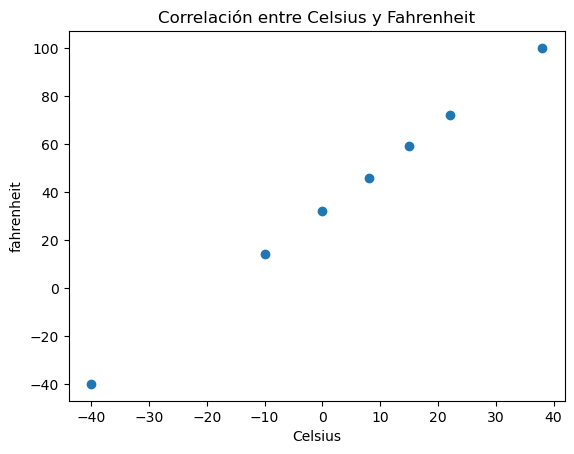

In [3]:
plt.scatter(celsius, fahrenheit)

plt.title('Correlación entre Celsius y Fahrenheit')
plt.xlabel('Celsius')
plt.ylabel('fahrenheit')

plt.show()

In [4]:
X_train = celsius
Y_train = fahrenheit

In [5]:
print("Creando el modelo")
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(1,)))
model.add(tf.keras.layers.Dense(units=1))

Creando el modelo


In [6]:
print("Compilando el modelo")
model.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss='mean_squared_error')

Compilando el modelo


In [7]:
print("Entrenando el modelo")
epochs_hist = model.fit(X_train, Y_train, epochs=100)

Entrenando el modelo
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 6788.5898
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3661.2825
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1710.1992
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 861.0699
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 883.6154
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1365.5194
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1849.7369
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 2054.3674
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1933.5216
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1585.1925
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1151.2375
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 759.5258
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 496.1107
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 393.3005
Epoch 15/100
1/1 ━━━━━━━━━━━━

Evaluando el modelo entrenado
Keys:
dict_keys(['loss'])


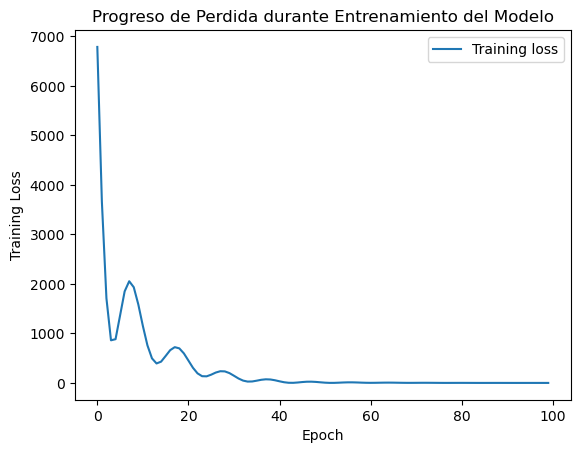

In [8]:
print("Evaluando el modelo entrenado")
print("Keys:")
print(epochs_hist.history.keys())

#Grafico
plt.plot(epochs_hist.history['loss'])
plt.title('Progreso de Perdida durante Entrenamiento del Modelo')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend(['Training loss'])
plt.show()

In [9]:
Temp_C = 100
Temp_C_array = np.array([[Temp_C]])
Temp_F = model.predict(Temp_C_array)

print("Temperatura de Prediccion: " + str(Temp_F))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Temperatura de Prediccion: [[211.3273]]


In [10]:
Temp_F = 9/5 * Temp_C + 32
print("Temperatura de Ecuacion: " + str(Temp_F))

Temperatura de Ecuacion: 212.0


In [11]:
import pandas as pd
import seaborn as sns

In [12]:
df_temperatura = pd.read_csv('celsius_a_fahrenheit.csv')

In [13]:
print(df_temperatura.head(5))

   Celsius  Fahrenheit
0      -50       -58.0
1      -40       -40.0
2      -30       -22.0
3      -20        -4.0
4      -10        14.0


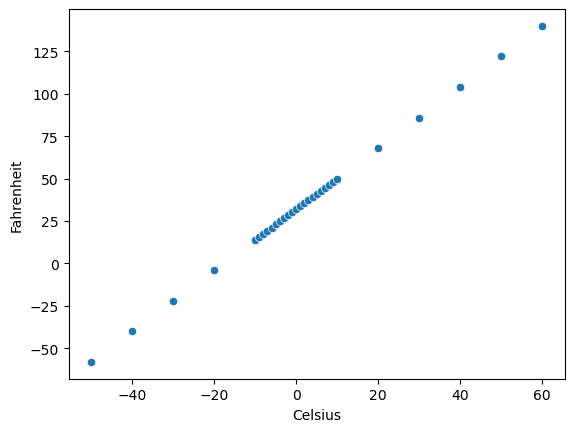

In [14]:
sns.scatterplot(x='Celsius', y='Fahrenheit', data=df_temperatura)
plt.show()

In [15]:
X_train = df_temperatura['Celsius']
Y_train = df_temperatura['Fahrenheit']

c:\Users\Leticia\anaconda3\envs\mi_entorno\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


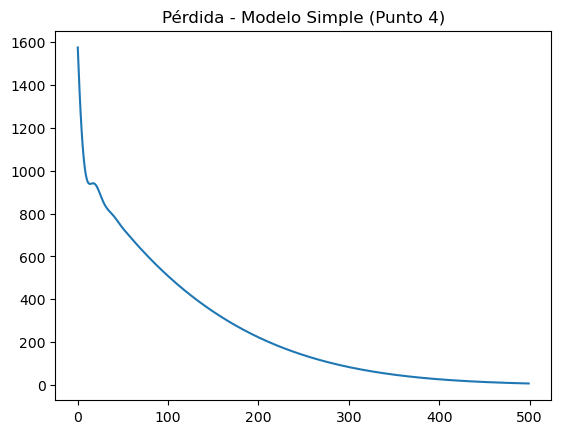

In [17]:
model_simple = tf.keras.Sequential()
model_simple.add(tf.keras.layers.Dense(units=1, input_shape=[1])) # Una sola capa

model_simple.compile(optimizer=tf.keras.optimizers.Adam(0.1), loss='mean_squared_error')

# Entrenamos
hist_simple = model_simple.fit(X_train, Y_train, epochs=500, verbose=False)

# Grafico
plt.plot(hist_simple.history['loss'])
plt.title('Pérdida - Modelo Simple (Punto 4)')
plt.show()

In [20]:
oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1]) 
oculta2 = tf.keras.layers.Dense(units=3)                 
salida = tf.keras.layers.Dense(units=1)                  

model_complejo = tf.keras.Sequential([oculta1, oculta2, salida])

model_complejo.compile(optimizer=tf.keras.optimizers.Adam(0.1), loss='mean_squared_error')

print("Entrenando modelo complejo...")
hist_complejo = model_complejo.fit(X_train, Y_train, epochs=500, verbose=False)

# --- MOSTRAR PESOS (Lo que pide el punto 6) ---
print("Pesos de la capa oculta 1:")
print(oculta1.get_weights()) 

print("Pesos de la capa oculta 2:")
print(oculta2.get_weights()) 

print("Pesos de la capa de salida:")
print(salida.get_weights()) 

c:\Users\Leticia\anaconda3\envs\mi_entorno\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando modelo complejo...
Pesos de la capa oculta 1:
[array([[ 0.44028586, -0.2012029 ,  0.07736942]], dtype=float32), array([ 3.5388994, -3.2779408,  2.6325223], dtype=float32)]
Pesos de la capa oculta 2:
[array([[ 0.6187068 , -1.3891692 , -1.0391368 ],
       [ 0.04518721,  0.90087414,  0.39987445],
       [ 0.12861009, -0.35979006, -0.4224626 ]], dtype=float32), array([ 2.9934194, -3.5063531, -3.6213522], dtype=float32)]
Pesos de la capa de salida:
[array([[ 0.73766303],
       [-1.5863528 ],
       [-0.5195031 ]], dtype=float32), array([3.4377315], dtype=float32)]


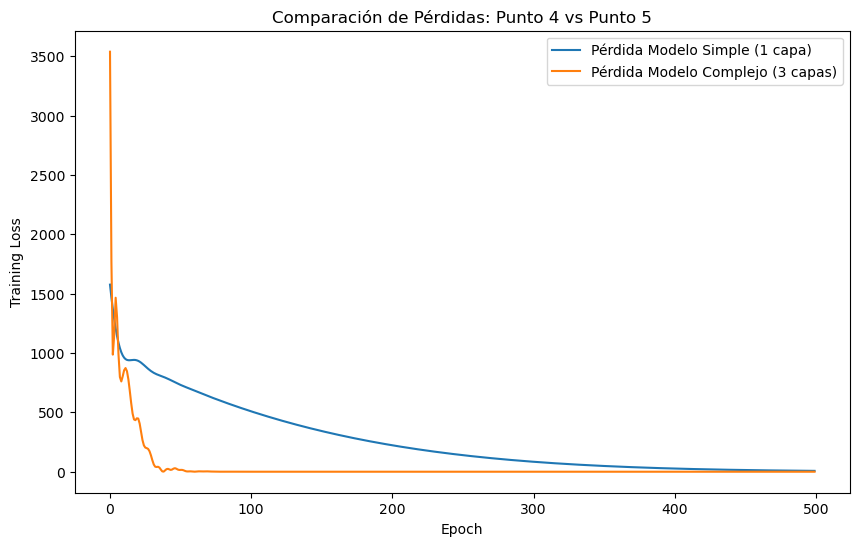

In [21]:
plt.figure(figsize=(10,6))
# Gráfica del Punto 4 (Modelo igual al ejemplo original pero con CSV)
plt.plot(hist_simple.history['loss'], label='Pérdida Modelo Simple (1 capa)') 

# Gráfica del Punto 5 (Modelo con capas extra)
plt.plot(hist_complejo.history['loss'], label='Pérdida Modelo Complejo (3 capas)') 

plt.title('Comparación de Pérdidas: Punto 4 vs Punto 5') 
plt.xlabel('Epoch') 
plt.ylabel('Training Loss') 
plt.legend()
plt.show()

# Cuestionario - Respuestas

### 1. 
### Adam: Es el que usamos. Es muy eficiente porque ajusta la velocidad de aprendizaje de forma automática. Es el estándar hoy en día porque llega rápido al resultado.
### SGD (Descenso de Gradiente Estocástico): Es el método más básico. Va dando pasos pequeños y constantes. El problema es que es mucho más lento, si lo hubiéramos usado, habríamos necesitado miles de épocas en lugar de 500 para obtener un buen resultado.
### RMSProp: Es similar a Adam pero más sencillo. Se usa mucho en problemas donde los datos cambian mucho en el tiempo.
### ¿Cómo cambian los resultados? Si cambias Adam por SGD, verías que tu gráfica de pérdida baja muy, muy despacio, y posiblemente la predicción final no sería tan exacta al terminar las 500 épocas.

### 2.
### El Mean Squared Error toma la diferencia entre la predicción y el valor real y la eleva al cuadrado. Esto es importante porque hace que los errores grandes se noten mucho más, obligando al modelo a corregirlos con prioridad.
### Se podría usar el Mean Absolute Error. A diferencia del MSE, este trata todos los errores por igual.
### ¿Cómo alteraría los resultados? Si usáramos MAE, el modelo podría ser un poco más lento para corregir pequeñas desviaciones, y nuestra conversión de grados Celsius a Fahrenheit podría tener variaciones de 1 o 2 grados en lugar de ser exacta.

### 3.
### Para el modelo complejo (3 capas), notamos que después de la época 60 o 70, la línea ya no baja más, se queda plana cerca del cero. Esto significa que con unas 100 épocas el modelo ya está listo para trabajar. En cambio, el modelo simple necesitó llegar casi a las 500 épocas para estabilizarse. Esto demuestra que agregar capas hace que el modelo aprenda "más rápido" con menos intentos.

### 4. 
### Son fundamentales porque las redes neuronales aprenden por repetición. En la primera pasada, el modelo adivina al azar. En la segunda, corrige un poco, y así sucesivamente. Sin suficientes épocas, el modelo no tiene tiempo de ajustar sus "pesos" internos para encontrar la fórmula correcta.

### 5.
### En el modelo original de una sola capa, no se especifica una función, por lo que usa una lineal, que es perfecta para predecir valores numéricos exactos.
### ¿Se puede cambiar? Sí, se pueden usar funciones como ReLU, que ayuda a la red a entender problemas más difíciles. ReLU lo que hace es ignorar los valores negativos, los vuelve cero y dejar pasar los positivos.

In [22]:
# Modificación con función de activación ReLU
oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1], activation='relu') 
oculta2 = tf.keras.layers.Dense(units=3, activation='relu')                 

salida = tf.keras.layers.Dense(units=1)                                    

model_relu = tf.keras.Sequential([oculta1, oculta2, salida])               

model_relu.compile(optimizer=tf.keras.optimizers.Adam(0.1), loss='mean_squared_error')

print("Entrenando modelo con activación ReLU...")
hist_relu = model_relu.fit(X_train, Y_train, epochs=500, verbose=False)   

print("Pesos de capa 1 (con ReLU):", oculta1.get_weights())             

c:\Users\Leticia\anaconda3\envs\mi_entorno\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando modelo con activación ReLU...
Pesos de capa 1 (con ReLU): [array([[ 0.7979123 ,  0.23080555, -0.66416776]], dtype=float32), array([ 4.966348,  4.824576, -3.162202], dtype=float32)]
